In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.datasets import make_blobs

In [2]:
X,y=make_blobs(n_samples=1000,centers=3,n_features=2)

In [3]:
X

array([[ -6.2637297 ,  -2.9213892 ],
       [-11.03763733,  -9.65120767],
       [ -9.50601924,  -9.77003152],
       ...,
       [-10.40093521,  -9.78692977],
       [ -7.92798312,  -0.34494501],
       [ -3.18180516,  -1.03609119]], shape=(1000, 2))

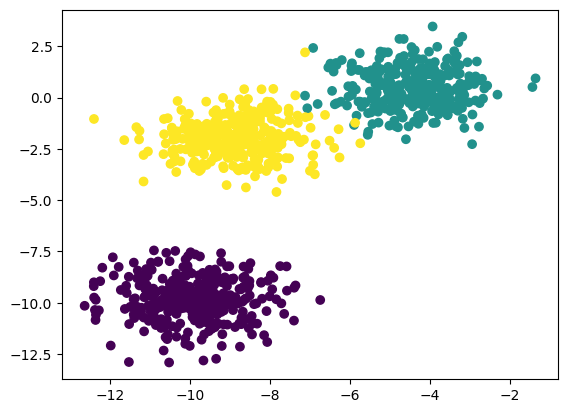

In [7]:
plt.scatter(X[:,0],X[:,1],c=y)

In [8]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [9]:
from sklearn.cluster import KMeans


In [11]:
#elvbow method to select K value
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)


In [12]:
wcss

[1600.000000000001,
 560.4328020383524,
 160.43218407585263,
 130.87908981752733,
 105.51561981906808,
 96.50077573466162,
 73.46492443535143,
 67.90580141008328,
 62.70093693921514,
 57.95192603930794]

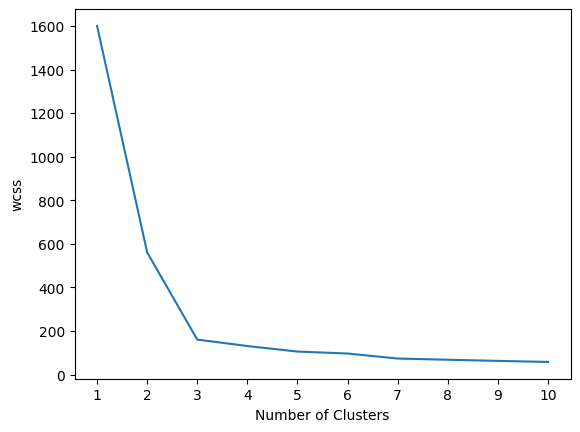

In [ ]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clusters")
plt.ylabel("wcss")
plt.show()
##with k=3 we shoud cluster it

In [16]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [17]:
kmeans.fit_predict(X_train_scaled)

array([2, 0, 0, 2, 1, 1, 0, 2, 1, 0, 2, 2, 2, 0, 2, 2, 2, 1, 0, 0, 0, 1,
       1, 1, 1, 2, 0, 1, 2, 2, 0, 2, 1, 1, 1, 0, 1, 0, 2, 2, 2, 0, 0, 1,
       2, 2, 1, 0, 2, 0, 2, 0, 0, 0, 2, 0, 2, 0, 2, 2, 0, 0, 0, 2, 2, 1,
       0, 2, 2, 1, 1, 2, 0, 1, 1, 2, 1, 1, 2, 0, 1, 1, 1, 2, 2, 1, 1, 1,
       0, 2, 1, 2, 1, 1, 2, 2, 2, 0, 2, 0, 0, 0, 2, 0, 2, 0, 1, 1, 0, 2,
       0, 1, 0, 2, 2, 0, 2, 2, 0, 1, 0, 1, 1, 1, 2, 0, 2, 2, 0, 1, 2, 1,
       1, 0, 1, 2, 2, 2, 0, 2, 1, 1, 1, 2, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       2, 0, 1, 1, 1, 2, 0, 2, 1, 2, 0, 2, 2, 0, 2, 0, 2, 1, 2, 1, 2, 0,
       0, 2, 0, 1, 0, 1, 0, 0, 1, 2, 2, 0, 2, 1, 2, 0, 0, 1, 2, 0, 0, 2,
       0, 2, 2, 2, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 2, 0, 0, 2, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 2, 1, 1, 1, 0, 1, 0, 2, 0, 0, 2, 1, 0, 1,
       1, 1, 0, 0, 1, 2, 0, 1, 2, 1, 0, 2, 2, 0, 1, 1, 2, 0, 2, 1, 0, 2,
       1, 1, 1, 2, 0, 2, 0, 2, 2, 1, 2, 1, 0, 2, 0, 2, 2, 2, 1, 0, 1, 0,
       1, 2, 2, 0, 2, 0, 2, 2, 0, 1, 0, 2, 2, 2, 2,

In [22]:
y_pred=kmeans.predict(X_test_scaled)

In [23]:
y_pred

array([1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 2, 2, 2, 1, 1, 0, 1, 2,
       1, 1, 1, 0, 0, 1, 0, 2, 2, 0, 2, 2, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 0, 1, 2, 2, 0, 1, 2, 0, 1, 2, 2, 1, 2, 1, 2, 0, 2, 2, 0, 0, 0,
       0, 1, 0, 1, 2, 2, 2, 0, 1, 2, 1, 2, 2, 2, 2, 2, 0, 0, 2, 2, 0, 2,
       0, 0, 0, 0, 2, 2, 1, 2, 0, 1, 2, 0, 1, 1, 1, 1, 0, 2, 1, 1, 2, 2,
       0, 0, 0, 0, 2, 0, 2, 2, 2, 0, 1, 2, 0, 0, 0, 1, 2, 2, 0, 1, 2, 0,
       2, 1, 1, 1, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 1, 1, 0, 2, 0, 2,
       1, 2, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 0,
       0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 2, 2, 2, 1, 0, 1, 0, 0,
       2, 1], dtype=int32)

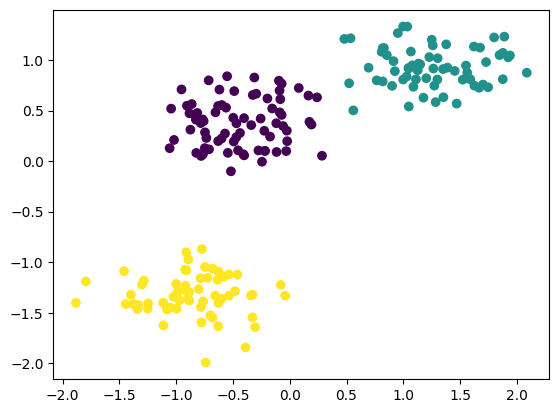

In [38]:
plt.scatter(X_test_scaled[:,0],X_test_scaled[:,1],c=y_pred)

In [25]:
#Validation the k value
## kneelocator
## silhoutee scoring
!pip install kneed

In [32]:
from kneed import KneeLocator


In [33]:
kl=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [34]:
kl.elbow

np.int64(3)

In [35]:
##silhoutee scoring
from sklearn.metrics import silhouette_score
sihouette_coe=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    sihouette_coe.append(score)

In [36]:
sihouette_coe

[0.5702464948386838,
 0.6805754803370427,
 0.5824730449844945,
 0.5001445682413969,
 0.4681258761095688,
 0.4642670646982809,
 0.37510656496560424,
 0.3278485730119695,
 0.3458779535654742]

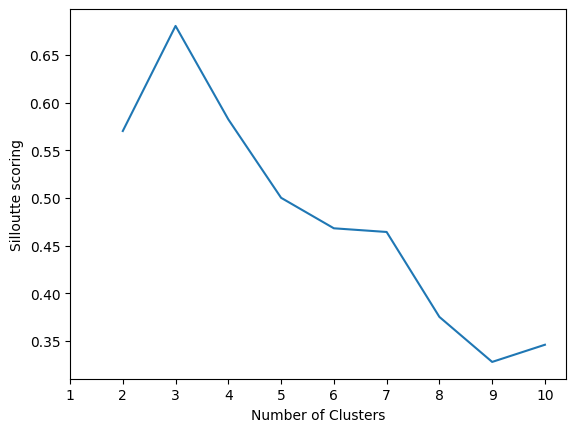

In [37]:
plt.plot(range(2,11),sihouette_coe)
plt.xticks(range(1,11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silloutte scoring")
plt.show()
##with k=3 we shoud cluster it